GENERATING 100 VARIANTS FOR MOODLE
Each variant - ONE Cloze question with 4 operations
Duplicate transitions are eliminated
Permutation-tolerant grading for alphabet Σ (any order accepted)
Feedback includes resulting automaton diagrams with unreachable states highlighted
Lost final states shown with orange circles

📁 Category: $course$/Finite Automata (100 variants) 1783061547


DISPLAYING FIRST 3 VARIANTS FOR REVIEW



CORRECT ANSWER:
  Q = p2,p3,q1,q2,q3,q4
  Σ = n,s,z
  q0 = q1
  F = p3,q1,q4
  New transitions:
    δ(q1,n) = p2
    δ(q1,s) = p2
    δ(q1,z) = p3
    δ(q4,n) = p2
    δ(q4,s) = p2
    δ(q4,z) = p3



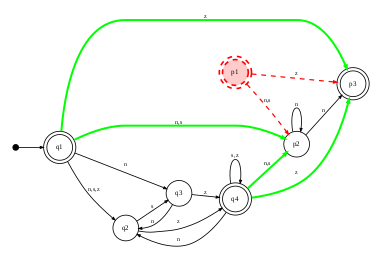


CORRECT ANSWER:
  Q = q0,r2,r3,s2,s3
  Σ = c,h,x
  q0 = q0
  F = q0,r2,r3,s2
  New transitions:
    δ(q0,c) = s2
    δ(q0,h) = r2,s3
    δ(q0,x) = s3



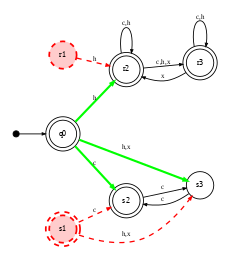


CORRECT ANSWER:
  Q = q0,t2,t3,t4
  Σ = x,y
  q0 = q0
  F = q0,t4
  New transitions:
    δ(q0,y) = t2,t4
    δ(t4,y) = t2,t4



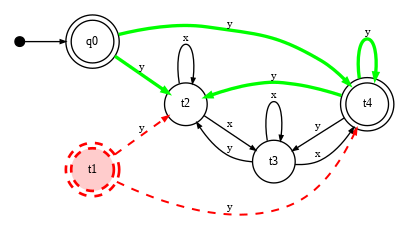


CORRECT ANSWER:
  Q = u1,u2,u3,u4
  Σ = c,t,x
  q0 = u1
  F = u1,u2
  New transitions:
    δ(u2,x) = u2



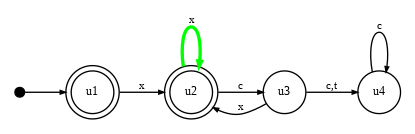


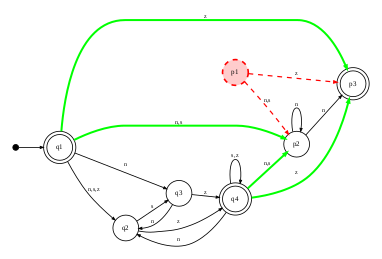


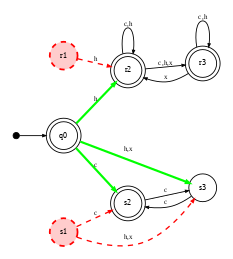


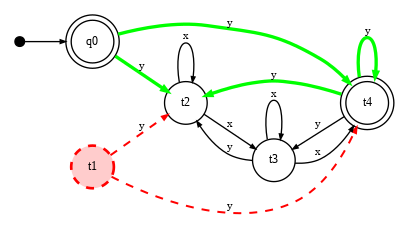


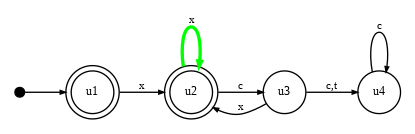


CORRECT ANSWER:
  Q = p2,p3,q1,q2,q3,q4
  Σ = r,x
  q0 = q1
  F = p3,q1,q4
  New transitions:
    δ(q1,r) = p2
    δ(q4,r) = p2



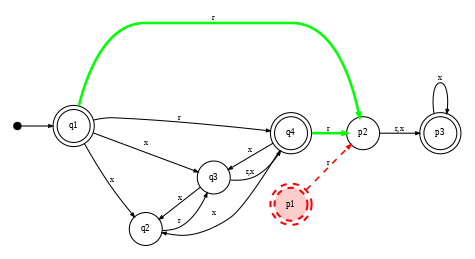


CORRECT ANSWER:
  Q = q0,r2,r3,s2,s3,s4
  Σ = n,p,t
  q0 = q0
  F = r2,r3,s3,s4
  New transitions:
    δ(q0,n) = r2,s2,s4
    δ(q0,t) = s2



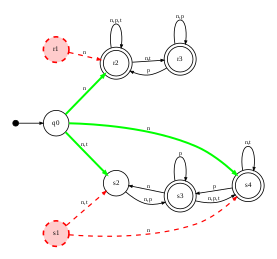


CORRECT ANSWER:
  Q = q0,t2,t3
  Σ = a,k,t
  q0 = q0
  F = q0,t2
  New transitions:
    δ(q0,a) = t3
    δ(q0,k) = t2,t3
    δ(t2,a) = t3
    δ(t2,k) = t2



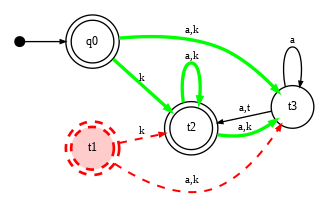


CORRECT ANSWER:
  Q = u1,u2,u3,u4
  Σ = c,x
  q0 = u1
  F = u1,u2
  New transitions:
    δ(u2,x) = u2



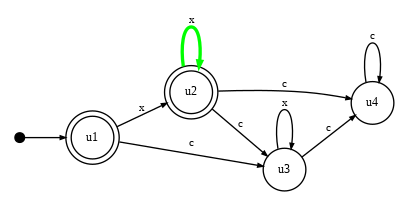


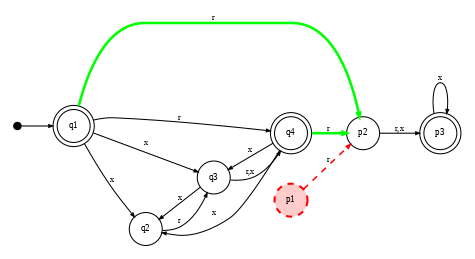


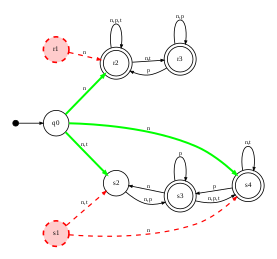


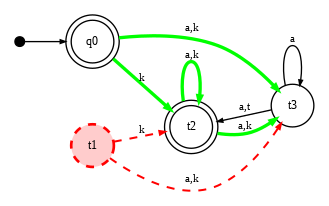


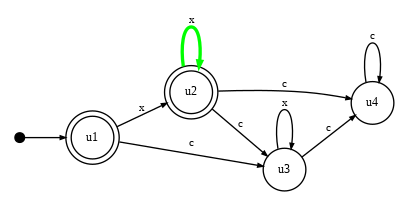


CORRECT ANSWER:
  Q = p2,p3,p4,q1,q2,q3,q4
  Σ = n,y
  q0 = q1
  F = p2,p3
  New transitions:
    δ(q1,n) = p2
    δ(q1,y) = p2,p3
    δ(q3,n) = p2
    δ(q3,y) = p2,p3



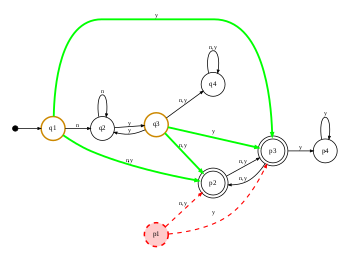


CORRECT ANSWER:
  Q = q0,r2,r3,s2,s3
  Σ = b,c
  q0 = q0
  F = q0,r3,s3
  New transitions:
    δ(q0,b) = s2,s3
    δ(q0,c) = r2



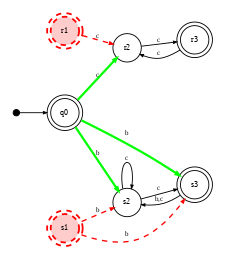


CORRECT ANSWER:
  Q = q0,t2,t3
  Σ = f,p,t
  q0 = q0
  F = q0,t3
  New transitions:
    δ(q0,f) = t2
    δ(q0,p) = t2
    δ(t3,f) = t2



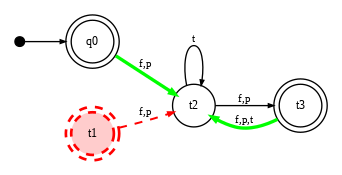


CORRECT ANSWER:
  Q = u1,u2,u3
  Σ = b,g,h
  q0 = u1
  F = u2,u3
  New transitions:
    δ(u2,b) = u3
    δ(u2,h) = u2
    δ(u3,b) = u3
    δ(u3,h) = u2



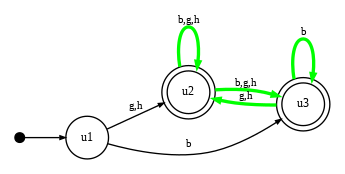


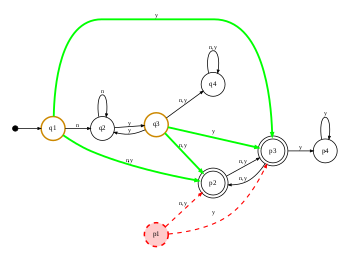


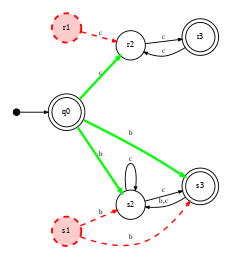


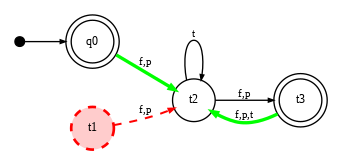


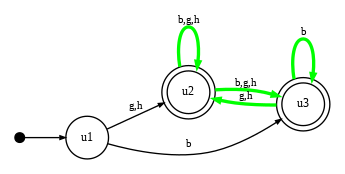



CREATING MOODLE XML FILE

✅ File: finite_automata_100_variants.xml
✅ Created 100 Cloze questions (one per variant)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📁 File downloaded to your computer

📌 IMPORT TO MOODLE:
1. Import the file into Moodle Question bank
2. Format: 'Moodle XML'
3. Create a Quiz
4. Add 'Random question' from this category
5. Number of questions: 1


In [5]:
import random
import itertools
from graphviz import Digraph
from collections import defaultdict
import xml.etree.ElementTree as ET
import base64
from google.colab import files
from IPython.display import display, Markdown, HTML
import time

# ============================================================
# AUTOMATA GENERATION
# ============================================================

def generate_random_alphabet():
    letters = ['a', 'b', 'c', 'd', 'f', 'g', 'h', 'k', 'm', 'n', 'p', 'r', 's', 't', 'x', 'y', 'z']
    return sorted(random.sample(letters, random.choice([2, 3])))

def remove_transitions_to_start(S, sigma, delta, q0):
    new_delta = {state: {symbol: set() for symbol in sigma} for state in S}
    for from_state in delta:
        for symbol in delta[from_state]:
            for to_state in delta[from_state][symbol]:
                if to_state != q0:
                    new_delta[from_state][symbol].add(to_state)
    return new_delta

def generate_random_nfa(prefix, sigma=None):
    n = random.choice([3, 4])
    sigma = sigma if sigma else generate_random_alphabet()

    S = [f'{prefix}{i}' for i in range(1, n+1)]
    q0 = f'{prefix}1'

    possible_final = S.copy()
    if len(possible_final) >= 2:
        F = random.sample(possible_final, 2)
    else:
        F = possible_final.copy()
    F.sort(key=lambda x: (x[0], int(x[1:])))

    delta = {state: {symbol: set() for symbol in sigma} for state in S}

    for i in range(2, n+1):
        from_state = f'{prefix}{i-1}'
        to_state = f'{prefix}{i}'
        symbol = random.choice(sigma)
        delta[from_state][symbol].add(to_state)

    for q in S:
        for s in sigma:
            if random.random() < 0.75:
                possible_targets = S.copy()
                if random.random() < 0.5:
                    possible_targets.append(q)
                target = random.choice(possible_targets)
                delta[q][s].add(target)

                if random.random() < 0.3 and len(delta[q][s]) < 3:
                    target2 = random.choice(possible_targets)
                    if target2 != target:
                        delta[q][s].add(target2)

    for q in S:
        has_any = any(len(delta[q][s]) > 0 for s in sigma)
        if not has_any:
            symbol = random.choice(sigma)
            if q != S[-1]:
                delta[q][symbol].add(S[S.index(q) + 1])
            else:
                delta[q][symbol].add(q)

    for symbol in sigma:
        used = False
        for q in S:
            if delta[q][symbol]:
                used = True
                break
        if not used:
            from_state = random.choice(S)
            to_state = random.choice([s for s in S if s != q0] + [from_state])
            delta[from_state][symbol].add(to_state)

    delta = remove_transitions_to_start(S, sigma, delta, q0)
    S.sort(key=lambda x: (x[0], int(x[1:])))

    return S, sigma, delta, q0, F


# ============================================================
# PERMUTATION GENERATOR FOR ALPHABET (TOLERANT GRADING)
# ============================================================

def generate_alphabet_permutations(elements):
    if not elements:
        return [""]
    perms = list(itertools.permutations(elements))
    return [",".join(p) for p in perms]


# ============================================================
# VISUALIZATION
# ============================================================

def draw_nfa_to_base64(S, sigma, delta, q0, F, highlight_new=None, unreachable_states=None, lost_final_states=None):
    """
    Draw NFA and return as base64 encoded PNG.
    ALL states from S are displayed with their correct final status.
    unreachable_states: list of states that are unreachable (shown with RED dashed borders)
    lost_final_states: list of states that were final but lost final status (shown with ORANGE circle)
    New transitions are highlighted in GREEN.
    """
    dot = Digraph(format='png')
    dot.attr(rankdir='LR', size='5,2.5', margin='0.1', nodesep='0.4', ranksep='0.4')
    dot.attr('node', shape='circle', width='0.45', height='0.45', fixedsize='true', fontsize='9')
    dot.attr('edge', arrowsize='0.4', fontsize='8')

    if unreachable_states is None:
        unreachable_states = []
    unreachable_set = set(unreachable_states)

    if lost_final_states is None:
        lost_final_states = []
    lost_final_set = set(lost_final_states)

    # Add start state
    dot.node('_start', shape='point', width='0.1', height='0.1')
    dot.edge('_start', q0, arrowsize='0.4')

    # Add ALL states
    for state in S:
        is_final = state in F
        is_lost_final = state in lost_final_set
        is_unreachable = state in unreachable_set

        if is_unreachable:
            # Unreachable states - RED dashed border, light red fill
            if is_final:
                dot.node(state,
                        shape='doublecircle',
                        style='filled,dashed',
                        color='red',
                        fontcolor='black',
                        penwidth='2',
                        fillcolor='#ffcccc')
            else:
                dot.node(state,
                        shape='circle',
                        style='filled,dashed',
                        color='red',
                        fontcolor='black',
                        penwidth='2',
                        fillcolor='#ffcccc')
        elif is_lost_final:
            # Lost final state - show as circle with orange border (solid, not dashed)
            dot.node(state,
                    shape='circle',
                    style='solid',
                    color='#cc8800',  # Orange/brown color
                    fontcolor='black',
                    penwidth='2')
        else:
            # Normal reachable states
            dot.node(state, shape='doublecircle' if is_final else 'circle')

    # Prepare transitions
    trans_dict = defaultdict(list)
    for from_state in delta:
        for symbol in delta[from_state]:
            for to_state in delta[from_state][symbol]:
                if to_state:
                    trans_dict[(from_state, to_state)].append(symbol)

    # New transitions set for highlighting (GREEN)
    new_transitions_set = set()
    if highlight_new:
        for from_state in highlight_new:
            for symbol in highlight_new[from_state]:
                for to_state in highlight_new[from_state][symbol]:
                    new_transitions_set.add((from_state, to_state, symbol))

    # Draw ALL transitions
    for (from_state, to_state), symbols in trans_dict.items():
        label = ','.join(sorted(symbols))

        from_unreachable = from_state in unreachable_set
        to_unreachable = to_state in unreachable_set

        is_new = False
        for symbol in symbols:
            if (from_state, to_state, symbol) in new_transitions_set:
                is_new = True
                break

        if is_new:
            # New transitions - GREEN thick
            dot.edge(from_state, to_state, label=label, color='green', penwidth='2.5')
        elif from_unreachable or to_unreachable:
            # Transitions from/to unreachable states - RED dashed
            dot.edge(from_state, to_state, label=label, style='dashed', color='red', penwidth='1.5')
        else:
            # Normal transitions - black
            dot.edge(from_state, to_state, label=label)

    img_data = dot.pipe(format='png')
    return base64.b64encode(img_data).decode('utf-8')


# ============================================================
# ANSWER CALCULATION - REMOVE UNREACHABLE STATES FROM Q AND F
# ============================================================

def get_concatenation_answer(A, B):
    sigma = A[1]

    # Q = Q1 ∪ (Q2 \ {q2_0})  - remove start state of B
    Q0 = sorted(set(A[0]) | (set(B[0]) - {B[3]}))

    # F = F1 ∪ (F2 \ {q2_0}) - remove start state of B from F
    if B[3] in B[4]:
        F0 = sorted(set(A[4]) | (set(B[4]) - {B[3]}))
    else:
        F0 = sorted(set(B[4]) - {B[3]})

    # Track which final states lost their final status
    # For concatenation: final states of A lose final status ONLY IF
    # the start state of B is NOT final
    if B[3] not in B[4]:
        # Start state of B is not final, so all final states of A lose final status
        lost_final = A[4].copy()
    else:
        # Start state of B IS final, so final states of A REMAIN final
        lost_final = []

    # Build FULL transition table (for diagram)
    result_delta = {}

    # 1. Copy ALL transitions from A (including from start state)
    for from_state in A[2]:
        result_delta[from_state] = {}
        for symbol in A[2][from_state]:
            result_delta[from_state][symbol] = set(A[2][from_state][symbol])

    # 2. Copy ALL transitions from B (INCLUDING from start state of B)
    for from_state in B[2]:
        if from_state not in result_delta:
            result_delta[from_state] = {}
        for symbol in B[2][from_state]:
            if symbol not in result_delta[from_state]:
                result_delta[from_state][symbol] = set()
            result_delta[from_state][symbol].update(B[2][from_state][symbol])

    # 3. Add NEW transitions
    new_transitions = {}
    for state in A[4]:  # For each final state of A
        for symbol in sigma:
            for to_state in B[2][B[3]][symbol]:  # Transitions from start state of B
                # Check if transition already exists
                existing = False
                if state in result_delta and symbol in result_delta[state]:
                    if to_state in result_delta[state][symbol]:
                        existing = True

                if not existing:
                    if state not in new_transitions:
                        new_transitions[state] = {}
                    if symbol not in new_transitions[state]:
                        new_transitions[state][symbol] = set()
                    new_transitions[state][symbol].add(to_state)

                    # Add to full table
                    if state not in result_delta:
                        result_delta[state] = {}
                    if symbol not in result_delta[state]:
                        result_delta[state][symbol] = set()
                    result_delta[state][symbol].add(to_state)

    # Unreachable state for concatenation: start state of B
    unreachable = [B[3]]

    return {'Q0': Q0, 'Sigma': sigma, 'q0': A[3], 'F0': F0,
            'new': new_transitions, 'delta': result_delta,
            'unreachable': unreachable, 'lost_final': lost_final}

def get_union_answer(C, D):
    sigma = C[1]

    # Q = {q0} ∪ (Q1 \ {q1_0}) ∪ (Q2 \ {q2_0})
    Q0 = sorted(['q0'] + [s for s in C[0] if s != C[3]] + [s for s in D[0] if s != D[3]])

    # F = (F1 \ {q1_0}) ∪ (F2 \ {q2_0}) ∪ {q0 if q1_0 ∈ F1 or q2_0 ∈ F2}
    F0 = set([s for s in C[4] if s != C[3]]) | set([s for s in D[4] if s != D[3]])
    if C[3] in C[4] or D[3] in D[4]:
        F0.add('q0')
    F0 = sorted(F0)

    # Build FULL transition table (for diagram)
    result_delta = {}

    # 1. Copy ALL transitions from C (INCLUDING from start state)
    for from_state in C[2]:
        result_delta[from_state] = {}
        for symbol in C[2][from_state]:
            result_delta[from_state][symbol] = set(C[2][from_state][symbol])

    # 2. Copy ALL transitions from D (INCLUDING from start state)
    for from_state in D[2]:
        if from_state not in result_delta:
            result_delta[from_state] = {}
        for symbol in D[2][from_state]:
            if symbol not in result_delta[from_state]:
                result_delta[from_state][symbol] = set()
            result_delta[from_state][symbol].update(D[2][from_state][symbol])

    # 3. Add NEW transitions from q0
    new_transitions = {}
    for symbol in sigma:
        for to_state in (C[2][C[3]][symbol] | D[2][D[3]][symbol]):
            existing = False
            if 'q0' in result_delta and symbol in result_delta['q0']:
                if to_state in result_delta['q0'][symbol]:
                    existing = True

            if not existing:
                if 'q0' not in new_transitions:
                    new_transitions['q0'] = {}
                if symbol not in new_transitions['q0']:
                    new_transitions['q0'][symbol] = set()
                new_transitions['q0'][symbol].add(to_state)

                if 'q0' not in result_delta:
                    result_delta['q0'] = {}
                if symbol not in result_delta['q0']:
                    result_delta['q0'][symbol] = set()
                result_delta['q0'][symbol].add(to_state)

    # Unreachable states for union: start states of C and D
    unreachable = [C[3], D[3]]

    # No lost final states for union
    lost_final = []

    return {'Q0': Q0, 'Sigma': sigma, 'q0': 'q0', 'F0': F0,
            'new': new_transitions, 'delta': result_delta,
            'unreachable': unreachable, 'lost_final': lost_final}

def get_star_answer(M):
    sigma = M[1]

    # Q = {q0} ∪ (Q \ {q1})
    Q0 = sorted(['q0'] + [s for s in M[0] if s != M[3]])

    # F = (F \ {q1}) ∪ {q0}
    F0 = sorted([s for s in M[4] if s != M[3]] + ['q0'])

    # Build FULL transition table (for diagram)
    result_delta = {}

    # 1. Copy ALL transitions from M (INCLUDING from start state)
    for from_state in M[2]:
        result_delta[from_state] = {}
        for symbol in M[2][from_state]:
            result_delta[from_state][symbol] = set(M[2][from_state][symbol])

    # 2. Add NEW transitions from q0
    new_transitions = {}
    for symbol in sigma:
        for to_state in M[2][M[3]][symbol]:
            existing = False
            if 'q0' in result_delta and symbol in result_delta['q0']:
                if to_state in result_delta['q0'][symbol]:
                    existing = True

            if not existing:
                if 'q0' not in new_transitions:
                    new_transitions['q0'] = {}
                if symbol not in new_transitions['q0']:
                    new_transitions['q0'][symbol] = set()
                new_transitions['q0'][symbol].add(to_state)

                if 'q0' not in result_delta:
                    result_delta['q0'] = {}
                if symbol not in result_delta['q0']:
                    result_delta['q0'][symbol] = set()
                result_delta['q0'][symbol].add(to_state)

    # 3. Add NEW transitions from final states
    for state in M[4]:
        if state != M[3]:
            for symbol in sigma:
                for to_state in M[2][M[3]][symbol]:
                    existing = False
                    if state in result_delta and symbol in result_delta[state]:
                        if to_state in result_delta[state][symbol]:
                            existing = True

                    if not existing:
                        if state not in new_transitions:
                            new_transitions[state] = {}
                        if symbol not in new_transitions[state]:
                            new_transitions[state][symbol] = set()
                        new_transitions[state][symbol].add(to_state)

                        if state not in result_delta:
                            result_delta[state] = {}
                        if symbol not in result_delta[state]:
                            result_delta[state][symbol] = set()
                        result_delta[state][symbol].add(to_state)

    # Unreachable state for Kleene star: start state of M
    unreachable = [M[3]]

    # No lost final states for star
    lost_final = []

    return {'Q0': Q0, 'Sigma': sigma, 'q0': 'q0', 'F0': F0,
            'new': new_transitions, 'delta': result_delta,
            'unreachable': unreachable, 'lost_final': lost_final}

def get_plus_answer(M):
    sigma = M[1]

    # Q = Q (no changes)
    Q0 = M[0]

    # F = F (no changes)
    F0 = M[4]

    # Build FULL transition table (for diagram)
    result_delta = {}

    # 1. Copy ALL transitions from M
    for from_state in M[2]:
        result_delta[from_state] = {}
        for symbol in M[2][from_state]:
            result_delta[from_state][symbol] = set(M[2][from_state][symbol])

    # 2. Add NEW transitions from final states through start state
    new_transitions = {}
    for state in M[4]:
        for symbol in sigma:
            for to_state in M[2][M[3]][symbol]:
                existing = False
                if state in result_delta and symbol in result_delta[state]:
                    if to_state in result_delta[state][symbol]:
                        existing = True

                if not existing:
                    if state not in new_transitions:
                        new_transitions[state] = {}
                    if symbol not in new_transitions[state]:
                        new_transitions[state][symbol] = set()
                    new_transitions[state][symbol].add(to_state)

                    if state not in result_delta:
                        result_delta[state] = {}
                    if symbol not in result_delta[state]:
                        result_delta[state][symbol] = set()
                    result_delta[state][symbol].add(to_state)

    # No unreachable states for positive iteration
    unreachable = []

    # No lost final states for plus
    lost_final = []

    return {'Q0': Q0, 'Sigma': sigma, 'q0': M[3], 'F0': F0,
            'new': new_transitions, 'delta': result_delta,
            'unreachable': unreachable, 'lost_final': lost_final}


# ============================================================
# HELPER FUNCTION TO COUNT NEW TRANSITIONS
# ============================================================

def count_new_transitions(answers):
    count = 0
    for op in ['concatenation', 'union', 'star', 'plus']:
        for from_state in answers[op]['new']:
            count += len(answers[op]['new'][from_state])
    return count


# ============================================================
# DISPLAY VARIANT FOR COLAB REVIEW
# ============================================================

def display_variant_for_review(var_num, A, B, C, D, M_star, M_plus, answers):
    sigma_conc = A[1]
    sigma_union = C[1]
    sigma_star = M_star[1]
    sigma_plus = M_plus[1]

    dot_A = Digraph(format='svg')
    dot_A.attr(rankdir='LR', size='4,2', margin='0.1', nodesep='0.3', ranksep='0.3')
    dot_A.attr('node', shape='circle', width='0.4', height='0.4', fixedsize='true', fontsize='8')
    dot_A.attr('edge', arrowsize='0.3', fontsize='7')
    dot_A.node('_start', shape='point', width='0.1', height='0.1')
    dot_A.edge('_start', A[3], arrowsize='0.3')
    for state in A[0]:
        dot_A.node(state, shape='doublecircle' if state in A[4] else 'circle')
    trans_dict = defaultdict(list)
    for from_state in A[2]:
        for symbol in A[2][from_state]:
            for to_state in A[2][from_state][symbol]:
                if to_state:
                    trans_dict[(from_state, to_state)].append(symbol)
    for (from_state, to_state), symbols in trans_dict.items():
        dot_A.edge(from_state, to_state, label=','.join(sorted(symbols)))
    svg_A = dot_A.pipe(format='svg').decode('utf-8').replace('width="', 'width="200" ')

    dot_B = Digraph(format='svg')
    dot_B.attr(rankdir='LR', size='4,2', margin='0.1', nodesep='0.3', ranksep='0.3')
    dot_B.attr('node', shape='circle', width='0.4', height='0.4', fixedsize='true', fontsize='8')
    dot_B.attr('edge', arrowsize='0.3', fontsize='7')
    dot_B.node('_start', shape='point', width='0.1', height='0.1')
    dot_B.edge('_start', B[3], arrowsize='0.3')
    for state in B[0]:
        dot_B.node(state, shape='doublecircle' if state in B[4] else 'circle')
    trans_dict = defaultdict(list)
    for from_state in B[2]:
        for symbol in B[2][from_state]:
            for to_state in B[2][from_state][symbol]:
                if to_state:
                    trans_dict[(from_state, to_state)].append(symbol)
    for (from_state, to_state), symbols in trans_dict.items():
        dot_B.edge(from_state, to_state, label=','.join(sorted(symbols)))
    svg_B = dot_B.pipe(format='svg').decode('utf-8').replace('width="', 'width="200" ')

    dot_C = Digraph(format='svg')
    dot_C.attr(rankdir='LR', size='4,2', margin='0.1', nodesep='0.3', ranksep='0.3')
    dot_C.attr('node', shape='circle', width='0.4', height='0.4', fixedsize='true', fontsize='8')
    dot_C.attr('edge', arrowsize='0.3', fontsize='7')
    dot_C.node('_start', shape='point', width='0.1', height='0.1')
    dot_C.edge('_start', C[3], arrowsize='0.3')
    for state in C[0]:
        dot_C.node(state, shape='doublecircle' if state in C[4] else 'circle')
    trans_dict = defaultdict(list)
    for from_state in C[2]:
        for symbol in C[2][from_state]:
            for to_state in C[2][from_state][symbol]:
                if to_state:
                    trans_dict[(from_state, to_state)].append(symbol)
    for (from_state, to_state), symbols in trans_dict.items():
        dot_C.edge(from_state, to_state, label=','.join(sorted(symbols)))
    svg_C = dot_C.pipe(format='svg').decode('utf-8').replace('width="', 'width="200" ')

    dot_D = Digraph(format='svg')
    dot_D.attr(rankdir='LR', size='4,2', margin='0.1', nodesep='0.3', ranksep='0.3')
    dot_D.attr('node', shape='circle', width='0.4', height='0.4', fixedsize='true', fontsize='8')
    dot_D.attr('edge', arrowsize='0.3', fontsize='7')
    dot_D.node('_start', shape='point', width='0.1', height='0.1')
    dot_D.edge('_start', D[3], arrowsize='0.3')
    for state in D[0]:
        dot_D.node(state, shape='doublecircle' if state in D[4] else 'circle')
    trans_dict = defaultdict(list)
    for from_state in D[2]:
        for symbol in D[2][from_state]:
            for to_state in D[2][from_state][symbol]:
                if to_state:
                    trans_dict[(from_state, to_state)].append(symbol)
    for (from_state, to_state), symbols in trans_dict.items():
        dot_D.edge(from_state, to_state, label=','.join(sorted(symbols)))
    svg_D = dot_D.pipe(format='svg').decode('utf-8').replace('width="', 'width="200" ')

    dot_Mstar = Digraph(format='svg')
    dot_Mstar.attr(rankdir='LR', size='4,2', margin='0.1', nodesep='0.3', ranksep='0.3')
    dot_Mstar.attr('node', shape='circle', width='0.4', height='0.4', fixedsize='true', fontsize='8')
    dot_Mstar.attr('edge', arrowsize='0.3', fontsize='7')
    dot_Mstar.node('_start', shape='point', width='0.1', height='0.1')
    dot_Mstar.edge('_start', M_star[3], arrowsize='0.3')
    for state in M_star[0]:
        dot_Mstar.node(state, shape='doublecircle' if state in M_star[4] else 'circle')
    trans_dict = defaultdict(list)
    for from_state in M_star[2]:
        for symbol in M_star[2][from_state]:
            for to_state in M_star[2][from_state][symbol]:
                if to_state:
                    trans_dict[(from_state, to_state)].append(symbol)
    for (from_state, to_state), symbols in trans_dict.items():
        dot_Mstar.edge(from_state, to_state, label=','.join(sorted(symbols)))
    svg_Mstar = dot_Mstar.pipe(format='svg').decode('utf-8').replace('width="', 'width="200" ')

    dot_Mplus = Digraph(format='svg')
    dot_Mplus.attr(rankdir='LR', size='4,2', margin='0.1', nodesep='0.3', ranksep='0.3')
    dot_Mplus.attr('node', shape='circle', width='0.4', height='0.4', fixedsize='true', fontsize='8')
    dot_Mplus.attr('edge', arrowsize='0.3', fontsize='7')
    dot_Mplus.node('_start', shape='point', width='0.1', height='0.1')
    dot_Mplus.edge('_start', M_plus[3], arrowsize='0.3')
    for state in M_plus[0]:
        dot_Mplus.node(state, shape='doublecircle' if state in M_plus[4] else 'circle')
    trans_dict = defaultdict(list)
    for from_state in M_plus[2]:
        for symbol in M_plus[2][from_state]:
            for to_state in M_plus[2][from_state][symbol]:
                if to_state:
                    trans_dict[(from_state, to_state)].append(symbol)
    for (from_state, to_state), symbols in trans_dict.items():
        dot_Mplus.edge(from_state, to_state, label=','.join(sorted(symbols)))
    svg_Mplus = dot_Mplus.pipe(format='svg').decode('utf-8').replace('width="', 'width="200" ')

    display(HTML(f"""
    <div style='page-break-before: always;'>
        <h2 style='background-color:#4CAF50;color:white;padding:10px;border-radius:5px;'>📚 VARIANT {var_num}</h2>
    </div>
    """))

    display(HTML(f"""
    <h3>1. CONCATENATION (A · B)</h3>
    <div style='display:flex; gap:20px; justify-content:center;'>
        <div style='text-align:center'><b>A</b><br>{svg_A}<br>Q = {{{','.join(A[0])}}}  F = {{{','.join(A[4])}}}</div>
        <div style='text-align:center'><b>B</b><br>{svg_B}<br>Q = {{{','.join(B[0])}}}  F = {{{','.join(B[4])}}}</div>
    </div>
    """))

    ans_conc = answers['concatenation']
    print(f"\nCORRECT ANSWER:")
    print(f"  Q = {','.join(ans_conc['Q0'])}")
    print(f"  Σ = {','.join(ans_conc['Sigma'])}")
    print(f"  q0 = {ans_conc['q0']}")
    print(f"  F = {','.join(ans_conc['F0'])}")
    if ans_conc['new']:
        print("  New transitions:")
        for state in sorted(ans_conc['new'].keys()):
            for symbol in sorted(ans_conc['new'][state].keys()):
                targets = ','.join(sorted(ans_conc['new'][state][symbol]))
                print(f"    δ({state},{symbol}) = {targets}")

    # For diagram we need to show ALL states with unreachable ones in RED
    # We use the full delta and full Q (including unreachable states)
    all_states_for_diagram = sorted(set(A[0]) | set(B[0]))
    # F for diagram needs to include all original final states
    all_final_for_diagram = sorted(set(A[4]) | set(B[4]))

    # Lost final states: all final states of A (if B start is not final)
    lost_final_states = ans_conc['lost_final']

    img_result_conc = draw_nfa_to_base64(
        all_states_for_diagram, ans_conc['Sigma'], ans_conc['delta'],
        ans_conc['q0'], all_final_for_diagram,
        highlight_new=ans_conc['new'],
        unreachable_states=ans_conc['unreachable'],
        lost_final_states=lost_final_states
    )
    display(HTML(f"""
    <div style='text-align:center; margin:20px 0; padding:15px; background-color:#f5f5f5; border-radius:5px;'>
        <b style='font-size:14px;'>📊 Resulting Automaton (ALL states shown):</b><br>
        <span style='color:green;'>● Green thick</span> - NEW transitions<br>
        <span style='color:red;'>● Red dashed</span> - Unreachable states/transitions (will be removed)<br>
        <span style='color:#cc8800;'>● Orange circle</span> - Lost final states (no longer accepting)<br>
        <img src="data:image/png;base64,{img_result_conc}" style='max-width:80%; border:1px solid #333; margin-top:10px;'>
    </div>
    """))

    display(HTML(f"""
    <h3>2. UNION (C ∪ D)</h3>
    <div style='display:flex; gap:20px; justify-content:center;'>
        <div style='text-align:center'><b>C</b><br>{svg_C}<br>Q = {{{','.join(C[0])}}}  F = {{{','.join(C[4])}}}</div>
        <div style='text-align:center'><b>D</b><br>{svg_D}<br>Q = {{{','.join(D[0])}}}  F = {{{','.join(D[4])}}}</div>
    </div>
    """))

    ans_union = answers['union']
    print(f"\nCORRECT ANSWER:")
    print(f"  Q = {','.join(ans_union['Q0'])}")
    print(f"  Σ = {','.join(ans_union['Sigma'])}")
    print(f"  q0 = {ans_union['q0']}")
    print(f"  F = {','.join(ans_union['F0'])}")
    if ans_union['new']:
        print("  New transitions:")
        for state in sorted(ans_union['new'].keys()):
            for symbol in sorted(ans_union['new'][state].keys()):
                targets = ','.join(sorted(ans_union['new'][state][symbol]))
                print(f"    δ({state},{symbol}) = {targets}")

    all_states_for_diagram = sorted(['q0'] + C[0] + D[0])
    all_final_for_diagram = sorted(set(C[4]) | set(D[4]) | ({'q0'} if (C[3] in C[4] or D[3] in D[4]) else set()))

    img_result_union = draw_nfa_to_base64(
        all_states_for_diagram, ans_union['Sigma'], ans_union['delta'],
        ans_union['q0'], all_final_for_diagram,
        highlight_new=ans_union['new'],
        unreachable_states=ans_union['unreachable'],
        lost_final_states=ans_union['lost_final']
    )
    display(HTML(f"""
    <div style='text-align:center; margin:20px 0; padding:15px; background-color:#f5f5f5; border-radius:5px;'>
        <b style='font-size:14px;'>📊 Resulting Automaton (ALL states shown):</b><br>
        <span style='color:green;'>● Green thick</span> - NEW transitions<br>
        <span style='color:red;'>● Red dashed</span> - Unreachable states/transitions (will be removed)<br>
        <img src="data:image/png;base64,{img_result_union}" style='max-width:80%; border:1px solid #333; margin-top:10px;'>
    </div>
    """))

    display(HTML(f"""
    <h3>3. KLEENE STAR (M*)</h3>
    <div style='text-align:center'>{svg_Mstar}<br><b>M</b><br>Q = {{{','.join(M_star[0])}}}  F = {{{','.join(M_star[4])}}}</div>
    """))

    ans_star = answers['star']
    print(f"\nCORRECT ANSWER:")
    print(f"  Q = {','.join(ans_star['Q0'])}")
    print(f"  Σ = {','.join(ans_star['Sigma'])}")
    print(f"  q0 = {ans_star['q0']}")
    print(f"  F = {','.join(ans_star['F0'])}")
    if ans_star['new']:
        print("  New transitions:")
        for state in sorted(ans_star['new'].keys()):
            for symbol in sorted(ans_star['new'][state].keys()):
                targets = ','.join(sorted(ans_star['new'][state][symbol]))
                print(f"    δ({state},{symbol}) = {targets}")

    all_states_for_diagram = sorted(['q0'] + M_star[0])
    all_final_for_diagram = sorted(M_star[4] + ['q0'])

    img_result_star = draw_nfa_to_base64(
        all_states_for_diagram, ans_star['Sigma'], ans_star['delta'],
        ans_star['q0'], all_final_for_diagram,
        highlight_new=ans_star['new'],
        unreachable_states=ans_star['unreachable'],
        lost_final_states=ans_star['lost_final']
    )
    display(HTML(f"""
    <div style='text-align:center; margin:20px 0; padding:15px; background-color:#f5f5f5; border-radius:5px;'>
        <b style='font-size:14px;'>📊 Resulting Automaton (ALL states shown):</b><br>
        <span style='color:green;'>● Green thick</span> - NEW transitions<br>
        <span style='color:red;'>● Red dashed</span> - Unreachable states/transitions (will be removed)<br>
        <img src="data:image/png;base64,{img_result_star}" style='max-width:80%; border:1px solid #333; margin-top:10px;'>
    </div>
    """))

    display(HTML(f"""
    <h3>4. POSITIVE ITERATION (M+)</h3>
    <div style='text-align:center'>{svg_Mplus}<br><b>M</b><br>Q = {{{','.join(M_plus[0])}}}  F = {{{','.join(M_plus[4])}}}</div>
    """))

    ans_plus = answers['plus']
    print(f"\nCORRECT ANSWER:")
    print(f"  Q = {','.join(ans_plus['Q0'])}")
    print(f"  Σ = {','.join(ans_plus['Sigma'])}")
    print(f"  q0 = {ans_plus['q0']}")
    print(f"  F = {','.join(ans_plus['F0'])}")
    if ans_plus['new']:
        print("  New transitions:")
        for state in sorted(ans_plus['new'].keys()):
            for symbol in sorted(ans_plus['new'][state].keys()):
                targets = ','.join(sorted(ans_plus['new'][state][symbol]))
                print(f"    δ({state},{symbol}) = {targets}")

    img_result_plus = draw_nfa_to_base64(
        ans_plus['Q0'], ans_plus['Sigma'], ans_plus['delta'],
        ans_plus['q0'], ans_plus['F0'],
        highlight_new=ans_plus['new'],
        unreachable_states=ans_plus['unreachable'],
        lost_final_states=ans_plus['lost_final']
    )
    display(HTML(f"""
    <div style='text-align:center; margin:20px 0; padding:15px; background-color:#f5f5f5; border-radius:5px;'>
        <b style='font-size:14px;'>📊 Resulting Automaton (ALL states shown):</b><br>
        <span style='color:green;'>● Green thick</span> - NEW transitions<br>
        <span style='color:red;'>● Red dashed</span> - Unreachable states/transitions (will be removed)<br>
        <img src="data:image/png;base64,{img_result_plus}" style='max-width:80%; border:1px solid #333; margin-top:10px;'>
    </div>
    """))

    print("\n" + "="*80)


# ============================================================
# DISPLAY RESULTING AUTOMATA ONLY (FOR COLAB REVIEW)
# ============================================================

# ============================================================
# DISPLAY RESULTING AUTOMATA ONLY (FOR COLAB REVIEW)
# ============================================================

def display_result_automata(var_num, answers):
    """
    Display ONLY the resulting automata for all 4 operations
    with highlighted new transitions, unreachable states, and lost final states
    """

    display(HTML(f"""
    <div style='page-break-before: always;'>
        <h2 style='background-color:#2196F3;color:white;padding:10px;border-radius:5px;'>📊 RESULTING AUTOMATA - VARIANT {var_num}</h2>
    </div>
    """))

    # 1. CONCATENATION - show ALL states including unreachable and lost final
    conc = answers['concatenation']
    # All states = Q0 (reachable) + unreachable states
    conc_all_states = sorted(set(conc['Q0']) | set(conc['unreachable']))
    # All final states for diagram = F0 + final states that are unreachable
    conc_all_final = conc['F0'].copy()
    # Also add any unreachable states that were originally final
    for state in conc['unreachable']:
        if state in conc['lost_final']:  # If it was final but lost status, it should not be shown as final
            pass  # Don't add to all_final because it's lost final status
        elif state in conc['Q0']:  # If it's reachable and final, it's already in F0
            pass
        # Actually, F0 already contains the correct final states after removal
        # For diagram we need to show the original final status for reachable states
        # And for unreachable states, we show them as red dashed with their original final status

    img_conc = draw_nfa_to_base64(
        conc_all_states,
        conc['Sigma'],
        conc['delta'],
        conc['q0'],
        conc['F0'],  # Use F0 as the correct final states after operation
        highlight_new=conc['new'],
        unreachable_states=conc['unreachable'],
        lost_final_states=conc['lost_final']
    )

    display(HTML(f"""
    <h3>1. CONCATENATION (A · B)</h3>
    <div style='text-align:center; margin:20px 0; padding:15px; background-color:#f5f5f5; border-radius:5px;'>
        <b>Resulting Automaton:</b><br>
        <span style='color:green;'>● Green</span> - NEW transitions<br>
        <span style='color:red;'>● Red dashed</span> - Unreachable states/transitions (removed from Q)<br>
        <span style='color:#cc8800;'>● Orange circle</span> - Lost final states (no longer accepting)<br>
        <span style='font-size:12px; color:#666;'>Q (all states shown) = {{{','.join(conc_all_states)}}}</span><br>
        <span style='font-size:12px; color:#666;'>F (final states) = {{{','.join(conc['F0'])}}}</span><br>
        <img src="data:image/png;base64,{img_conc}" style='max-width:80%; border:1px solid #333; margin-top:10px;'>
    </div>
    """))

    # 2. UNION - show ALL states including unreachable
    union = answers['union']
    union_all_states = sorted(set(union['Q0']) | set(union['unreachable']))

    img_union = draw_nfa_to_base64(
        union_all_states,
        union['Sigma'],
        union['delta'],
        union['q0'],
        union['F0'],
        highlight_new=union['new'],
        unreachable_states=union['unreachable'],
        lost_final_states=union['lost_final']
    )

    display(HTML(f"""
    <h3>2. UNION (C ∪ D)</h3>
    <div style='text-align:center; margin:20px 0; padding:15px; background-color:#f5f5f5; border-radius:5px;'>
        <b>Resulting Automaton:</b><br>
        <span style='color:green;'>● Green</span> - NEW transitions<br>
        <span style='color:red;'>● Red dashed</span> - Unreachable states/transitions (removed from Q)<br>
        <span style='font-size:12px; color:#666;'>Q (all states shown) = {{{','.join(union_all_states)}}}</span><br>
        <span style='font-size:12px; color:#666;'>F (final states) = {{{','.join(union['F0'])}}}</span><br>
        <img src="data:image/png;base64,{img_union}" style='max-width:80%; border:1px solid #333; margin-top:10px;'>
    </div>
    """))

    # 3. KLEENE STAR - show ALL states including unreachable
    star = answers['star']
    star_all_states = sorted(set(star['Q0']) | set(star['unreachable']))

    img_star = draw_nfa_to_base64(
        star_all_states,
        star['Sigma'],
        star['delta'],
        star['q0'],
        star['F0'],
        highlight_new=star['new'],
        unreachable_states=star['unreachable'],
        lost_final_states=star['lost_final']
    )

    display(HTML(f"""
    <h3>3. KLEENE STAR (M*)</h3>
    <div style='text-align:center; margin:20px 0; padding:15px; background-color:#f5f5f5; border-radius:5px;'>
        <b>Resulting Automaton:</b><br>
        <span style='color:green;'>● Green</span> - NEW transitions<br>
        <span style='color:red;'>● Red dashed</span> - Unreachable states/transitions (removed from Q)<br>
        <span style='font-size:12px; color:#666;'>Q (all states shown) = {{{','.join(star_all_states)}}}</span><br>
        <span style='font-size:12px; color:#666;'>F (final states) = {{{','.join(star['F0'])}}}</span><br>
        <img src="data:image/png;base64,{img_star}" style='max-width:80%; border:1px solid #333; margin-top:10px;'>
    </div>
    """))

    # 4. POSITIVE ITERATION - show ALL states (no unreachable)
    plus = answers['plus']
    plus_all_states = sorted(set(plus['Q0']) | set(plus['unreachable']))

    img_plus = draw_nfa_to_base64(
        plus_all_states,
        plus['Sigma'],
        plus['delta'],
        plus['q0'],
        plus['F0'],
        highlight_new=plus['new'],
        unreachable_states=plus['unreachable'],
        lost_final_states=plus['lost_final']
    )

    display(HTML(f"""
    <h3>4. POSITIVE ITERATION (M+)</h3>
    <div style='text-align:center; margin:20px 0; padding:15px; background-color:#f5f5f5; border-radius:5px;'>
        <b>Resulting Automaton:</b><br>
        <span style='color:green;'>● Green</span> - NEW transitions<br>
        <span style='font-size:12px; color:#666;'>Q (all states) = {{{','.join(plus_all_states)}}}</span><br>
        <span style='font-size:12px; color:#666;'>F (final states) = {{{','.join(plus['F0'])}}}</span><br>
        <img src="data:image/png;base64,{img_plus}" style='max-width:80%; border:1px solid #333; margin-top:10px;'>
    </div>
    """))

    print("\n" + "="*80)

# ============================================================
# CLOZE QUESTION CREATION
# ============================================================
def create_cloze_question(var_num, images_base64, answers, new_count):
    question = ET.Element("question", type="cloze")

    name = ET.SubElement(question, "name")
    name_text = ET.SubElement(name, "text")
    name_text.text = f"Variant_{var_num:02d}"

    questiontext = ET.SubElement(question, "questiontext", format="html")
    text_elem = ET.SubElement(questiontext, "text")

    conc = answers['concatenation']
    union = answers['union']
    star = answers['star']
    plus = answers['plus']

    q0_conc = ",".join(conc['Q0'])
    sigma_conc = ",".join(conc['Sigma'])
    f0_conc = ",".join(conc['F0'])

    q0_union = ",".join(union['Q0'])
    sigma_union = ",".join(union['Sigma'])
    f0_union = ",".join(union['F0'])

    q0_star = ",".join(star['Q0'])
    sigma_star = ",".join(star['Sigma'])
    f0_star = ",".join(star['F0'])

    q0_plus = ",".join(plus['Q0'])
    sigma_plus = ",".join(plus['Sigma'])
    f0_plus = ",".join(plus['F0'])

    # Generate all permutations for alphabet (tolerant grading)
    sigma_perms = generate_alphabet_permutations(conc['Sigma'])
    sigma_answers = "".join([f"~%100%{p}" for p in sigma_perms])

    # Collect all new transitions
    all_new = []
    for state in sorted(conc['new'].keys()):
        for symbol in sorted(conc['new'][state].keys()):
            targets = ','.join(sorted(conc['new'][state][symbol]))
            full_transition = f"δ({state},{symbol})={targets}"
            all_new.append(('conc', full_transition))

    for state in sorted(union['new'].keys()):
        for symbol in sorted(union['new'][state].keys()):
            targets = ','.join(sorted(union['new'][state][symbol]))
            full_transition = f"δ({state},{symbol})={targets}"
            all_new.append(('union', full_transition))

    for state in sorted(star['new'].keys()):
        for symbol in sorted(star['new'][state].keys()):
            targets = ','.join(sorted(star['new'][state][symbol]))
            full_transition = f"δ({state},{symbol})={targets}"
            all_new.append(('star', full_transition))

    for state in sorted(plus['new'].keys()):
        for symbol in sorted(plus['new'][state].keys()):
            targets = ','.join(sorted(plus['new'][state][symbol]))
            full_transition = f"δ({state},{symbol})={targets}"
            all_new.append(('plus', full_transition))

    # Build the question text
    text_str = f"""
<h2>VARIANT {var_num}</h2>

<div style="background-color:#f0f8ff; padding:15px; margin:10px 0; border:1px solid #4CAF50; border-radius:5px;">
    <b>📌 GENERAL TASK:</b><br>
    For each operation below, construct the resulting automaton M₀
    as a 5-tuple: <b>M₀ = (Q, Σ, δ, q₀, F)</b>.<br>
    Write the transition function δ <b>ONLY FOR NEW TRANSITIONS</b> that appear
    as a result of applying the algorithm. Transitions that already existed
    in the original automata should not be written.
</div>

<div style="background-color:#fff3cd; padding:12px; margin:10px 0; border-left:4px solid #ffc107;">
    <b>📌 HOW TO FORMAT YOUR ANSWERS:</b><br>
    • <b>Q, F</b> - write elements separated by commas, <b>WITHOUT curly braces</b> and <b>WITHOUT spaces</b><br>
    &nbsp;&nbsp;Example: <b>q1,q2,q3</b><br>
    • <b>Σ</b> - write symbols separated by commas, <b>WITHOUT spaces</b><br>
    &nbsp;&nbsp;Example: <b>a,b,c</b> (any order accepted)<br>
    • <b>q0</b> - write only the state name (e.g., <b>q0</b> or <b>q1</b>)<br>
    • <b>New transitions</b> - write in the format: <b>δ(state,symbol)=set_of_states</b><br>
    &nbsp;&nbsp;Example: <b>δ(q3,a)=q2,q4</b><br>
    • All sets must be <b>sorted alphabetically</b>
</div>

<h3>1. CONCATENATION (A · B)</h3>
<div style="display:flex; flex-wrap:wrap; justify-content:center;">
    <img src="data:image/png;base64,{images_base64[0]}" alt="A" style="max-width:45%; margin:5px; border:1px solid #333;">
    <img src="data:image/png;base64,{images_base64[1]}" alt="B" style="max-width:45%; margin:5px; border:1px solid #333;">
</div>
<p>
Q = {{1:SHORTANSWER:~%100%{q0_conc}}}<br>
Σ = {{1:SHORTANSWER:{sigma_answers}}}<br>
q0 = {{1:SHORTANSWER:~%100%{conc['q0']}}}<br>
F = {{1:SHORTANSWER:~%100%{f0_conc}}}
</p>
"""

    # Add new transition fields for concatenation
    for op, full_transition in all_new:
        if op == 'conc':
            text_str += f'<p>New transition: {{1:SHORTANSWER:~%100%{full_transition}}}</p>\n'

    text_str += f"""
<h3>2. UNION (C ∪ D)</h3>
<div style="display:flex; flex-wrap:wrap; justify-content:center;">
    <img src="data:image/png;base64,{images_base64[2]}" alt="C" style="max-width:45%; margin:5px; border:1px solid #333;">
    <img src="data:image/png;base64,{images_base64[3]}" alt="D" style="max-width:45%; margin:5px; border:1px solid #333;">
</div>
<p>
Q = {{1:SHORTANSWER:~%100%{q0_union}}}<br>
Σ = {{1:SHORTANSWER:~%100%{sigma_union}}}<br>
q0 = {{1:SHORTANSWER:~%100%{union['q0']}}}<br>
F = {{1:SHORTANSWER:~%100%{f0_union}}}
</p>
"""

    for op, full_transition in all_new:
        if op == 'union':
            text_str += f'<p>New transition: {{1:SHORTANSWER:~%100%{full_transition}}}</p>\n'

    text_str += f"""
<h3>3. KLEENE STAR (M*)</h3>
<div style="display:flex; justify-content:center;">
    <img src="data:image/png;base64,{images_base64[4]}" alt="M*" style="max-width:45%; margin:5px; border:1px solid #333;">
</div>
<p>
Q = {{1:SHORTANSWER:~%100%{q0_star}}}<br>
Σ = {{1:SHORTANSWER:~%100%{sigma_star}}}<br>
q0 = {{1:SHORTANSWER:~%100%{star['q0']}}}<br>
F = {{1:SHORTANSWER:~%100%{f0_star}}}
</p>
"""

    for op, full_transition in all_new:
        if op == 'star':
            text_str += f'<p>New transition: {{1:SHORTANSWER:~%100%{full_transition}}}</p>\n'

    text_str += f"""
<h3>4. POSITIVE ITERATION (M+)</h3>
<div style="display:flex; justify-content:center;">
    <img src="data:image/png;base64,{images_base64[5]}" alt="M+" style="max-width:45%; margin:5px; border:1px solid #333;">
</div>
<p>
Q = {{1:SHORTANSWER:~%100%{q0_plus}}}<br>
Σ = {{1:SHORTANSWER:~%100%{sigma_plus}}}<br>
q0 = {{1:SHORTANSWER:~%100%{plus['q0']}}}<br>
F = {{1:SHORTANSWER:~%100%{f0_plus}}}
</p>
"""

    for op, full_transition in all_new:
        if op == 'plus':
            text_str += f'<p>New transition: {{1:SHORTANSWER:~%100%{full_transition}}}</p>\n'

    text_elem.text = text_str

    # ============================================================
    # GRADER FEEDBACK WITH RESULTING AUTOMATON DIAGRAMS
    # ============================================================
    graderinfo = ET.SubElement(question, "graderinfo", format="html")
    graderinfo_text = ET.SubElement(graderinfo, "text")

    # Generate diagrams for all resulting automata
    # Concatenation
    conc_all_states = sorted(set(conc['Q0']) | set(conc['unreachable']))
    img_conc = draw_nfa_to_base64(
        conc_all_states, conc['Sigma'], conc['delta'],
        conc['q0'], conc['F0'],
        highlight_new=conc['new'],
        unreachable_states=conc['unreachable'],
        lost_final_states=conc['lost_final']
    )

    # Union
    union_all_states = sorted(set(union['Q0']) | set(union['unreachable']))
    img_union = draw_nfa_to_base64(
        union_all_states, union['Sigma'], union['delta'],
        union['q0'], union['F0'],
        highlight_new=union['new'],
        unreachable_states=union['unreachable'],
        lost_final_states=union['lost_final']
    )

    # Star
    star_all_states = sorted(set(star['Q0']) | set(star['unreachable']))
    img_star = draw_nfa_to_base64(
        star_all_states, star['Sigma'], star['delta'],
        star['q0'], star['F0'],
        highlight_new=star['new'],
        unreachable_states=star['unreachable'],
        lost_final_states=star['lost_final']
    )

    # Plus
    img_plus = draw_nfa_to_base64(
        plus['Q0'], plus['Sigma'], plus['delta'],
        plus['q0'], plus['F0'],
        highlight_new=plus['new'],
        unreachable_states=plus['unreachable'],
        lost_final_states=plus['lost_final']
    )

    grad_str = f'<h3>✅ CORRECT ANSWERS FOR VARIANT {var_num}</h3>\n'
    grad_str += '<p><b>Grading criteria:</b> each question - 1 point<br>Recommended quiz maximum - 10 points</p>\n'
    grad_str += '<hr>\n'

    # Concatenation
    grad_str += '\n<h4>1. CONCATENATION</h4>\n'
    grad_str += f'<b>Q =</b> {q0_conc}<br>\n'
    grad_str += f'<b>Σ =</b> {sigma_conc}<br>\n'
    grad_str += f'<b>q₀ =</b> {conc["q0"]}<br>\n'
    grad_str += f'<b>F =</b> {f0_conc}<br>\n'
    if any(op == 'conc' for op, _ in all_new):
        grad_str += '<b>New transitions:</b><br>\n'
        for op, full_transition in all_new:
            if op == 'conc':
                grad_str += f'&nbsp;&nbsp;{full_transition}<br>\n'
    grad_str += f'<br><b>📊 Resulting Automaton:</b><br>\n'
    grad_str += f'<img src="data:image/png;base64,{img_conc}" style="max-width:80%; border:1px solid #333; margin:10px 0;"><br>\n'
    grad_str += '<span style="color:green;">● Green</span> - NEW transitions &nbsp;|&nbsp; '
    grad_str += '<span style="color:red;">● Red dashed</span> - Unreachable states/transitions &nbsp;|&nbsp; '
    grad_str += '<span style="color:#cc8800;">● Orange circle</span> - Lost final states<br>\n'
    grad_str += '<hr>\n'

    # Union
    grad_str += '\n<h4>2. UNION</h4>\n'
    grad_str += f'<b>Q =</b> {q0_union}<br>\n'
    grad_str += f'<b>Σ =</b> {sigma_union}<br>\n'
    grad_str += f'<b>q₀ =</b> {union["q0"]}<br>\n'
    grad_str += f'<b>F =</b> {f0_union}<br>\n'
    if any(op == 'union' for op, _ in all_new):
        grad_str += '<b>New transitions:</b><br>\n'
        for op, full_transition in all_new:
            if op == 'union':
                grad_str += f'&nbsp;&nbsp;{full_transition}<br>\n'
    grad_str += f'<br><b>📊 Resulting Automaton:</b><br>\n'
    grad_str += f'<img src="data:image/png;base64,{img_union}" style="max-width:80%; border:1px solid #333; margin:10px 0;"><br>\n'
    grad_str += '<span style="color:green;">● Green</span> - NEW transitions &nbsp;|&nbsp; '
    grad_str += '<span style="color:red;">● Red dashed</span> - Unreachable states/transitions<br>\n'
    grad_str += '<hr>\n'

    # Star
    grad_str += '\n<h4>3. KLEENE STAR</h4>\n'
    grad_str += f'<b>Q =</b> {q0_star}<br>\n'
    grad_str += f'<b>Σ =</b> {sigma_star}<br>\n'
    grad_str += f'<b>q₀ =</b> {star["q0"]}<br>\n'
    grad_str += f'<b>F =</b> {f0_star}<br>\n'
    if any(op == 'star' for op, _ in all_new):
        grad_str += '<b>New transitions:</b><br>\n'
        for op, full_transition in all_new:
            if op == 'star':
                grad_str += f'&nbsp;&nbsp;{full_transition}<br>\n'
    grad_str += f'<br><b>📊 Resulting Automaton:</b><br>\n'
    grad_str += f'<img src="data:image/png;base64,{img_star}" style="max-width:80%; border:1px solid #333; margin:10px 0;"><br>\n'
    grad_str += '<span style="color:green;">● Green</span> - NEW transitions &nbsp;|&nbsp; '
    grad_str += '<span style="color:red;">● Red dashed</span> - Unreachable states/transitions<br>\n'
    grad_str += '<hr>\n'

    # Plus
    grad_str += '\n<h4>4. POSITIVE ITERATION</h4>\n'
    grad_str += f'<b>Q =</b> {q0_plus}<br>\n'
    grad_str += f'<b>Σ =</b> {sigma_plus}<br>\n'
    grad_str += f'<b>q₀ =</b> {plus["q0"]}<br>\n'
    grad_str += f'<b>F =</b> {f0_plus}<br>\n'
    if any(op == 'plus' for op, _ in all_new):
        grad_str += '<b>New transitions:</b><br>\n'
        for op, full_transition in all_new:
            if op == 'plus':
                grad_str += f'&nbsp;&nbsp;{full_transition}<br>\n'
    grad_str += f'<br><b>📊 Resulting Automaton:</b><br>\n'
    grad_str += f'<img src="data:image/png;base64,{img_plus}" style="max-width:80%; border:1px solid #333; margin:10px 0;"><br>\n'
    grad_str += '<span style="color:green;">● Green</span> - NEW transitions<br>\n'

    graderinfo_text.text = grad_str

    penalty = ET.SubElement(question, "penalty")
    penalty.text = "0.0"

    return question


# ============================================================
# MAIN GENERATION (100 VARIANTS)
# ============================================================

print("="*80)
print("GENERATING 100 VARIANTS FOR MOODLE")
print("="*80)
print("Each variant - ONE Cloze question with 4 operations")
print("Duplicate transitions are eliminated")
print("Permutation-tolerant grading for alphabet Σ (any order accepted)")
print("Feedback includes resulting automaton diagrams with unreachable states highlighted")
print("Lost final states shown with orange circles")
print("="*80)

timestamp = int(time.time())
category_name = f"$course$/Finite Automata (100 variants) {timestamp}"

root = ET.Element("quiz")

category = ET.SubElement(root, "question", type="category")
cat_name = ET.SubElement(category, "category")
cat_text = ET.SubElement(cat_name, "text")
cat_text.text = category_name

print(f"\n📁 Category: {category_name}\n")

all_variants_data = []

for var_num in range(1, 101):
    #print(f"Generating variant {var_num} of 100...")

    while True:
        sigma_conc = generate_random_alphabet()
        sigma_union = generate_random_alphabet()
        sigma_star = generate_random_alphabet()
        sigma_plus = generate_random_alphabet()

        A = generate_random_nfa('q', sigma=sigma_conc)
        B = generate_random_nfa('p', sigma=sigma_conc)
        C = generate_random_nfa('r', sigma=sigma_union)
        D = generate_random_nfa('s', sigma=sigma_union)
        M_star = generate_random_nfa('t', sigma=sigma_star)
        M_plus = generate_random_nfa('u', sigma=sigma_plus)

        answers = {
            'concatenation': get_concatenation_answer(A, B),
            'union': get_union_answer(C, D),
            'star': get_star_answer(M_star),
            'plus': get_plus_answer(M_plus)
        }

        new_count = count_new_transitions(answers)
        if new_count >= 1:
            break

    if var_num <= 3:
        all_variants_data.append({
            'var_num': var_num,
            'A': A, 'B': B, 'C': C, 'D': D, 'M_star': M_star, 'M_plus': M_plus,
            'answers': answers
        })

    # Generate images as base64 PNG
    img_A = draw_nfa_to_base64(A[0], A[1], A[2], A[3], A[4])
    img_B = draw_nfa_to_base64(B[0], B[1], B[2], B[3], B[4])
    img_C = draw_nfa_to_base64(C[0], C[1], C[2], C[3], C[4])
    img_D = draw_nfa_to_base64(D[0], D[1], D[2], D[3], D[4])
    img_Mstar = draw_nfa_to_base64(M_star[0], M_star[1], M_star[2], M_star[3], M_star[4])
    img_Mplus = draw_nfa_to_base64(M_plus[0], M_plus[1], M_plus[2], M_plus[3], M_plus[4])

    images_base64 = [img_A, img_B, img_C, img_D, img_Mstar, img_Mplus]

    q = create_cloze_question(var_num, images_base64, answers, new_count)
    root.append(q)

print("\n" + "="*80)
print("DISPLAYING FIRST 3 VARIANTS FOR REVIEW")
print("="*80)

for i in range(3):
    v = all_variants_data[i]
    display_variant_for_review(v['var_num'], v['A'], v['B'], v['C'], v['D'], v['M_star'], v['M_plus'], v['answers'])

    # Display resulting automata only
    display_result_automata(v['var_num'], v['answers'])

print("\n" + "="*80)
print("CREATING MOODLE XML FILE")
print("="*80)

filename = "finite_automata_100_variants.xml"
tree = ET.ElementTree(root)
tree.write(filename, encoding="UTF-8", xml_declaration=True)

print(f"\n✅ File: {filename}")
print(f"✅ Created 100 Cloze questions (one per variant)")

try:
    files.download(filename)
    print("\n📁 File downloaded to your computer")
except:
    print("\n📁 Manual download: find '{}' in the folder and download".format(filename))

print("\n" + "="*80)
print("📌 IMPORT TO MOODLE:")
print("="*80)
print("1. Import the file into Moodle Question bank")
print("2. Format: 'Moodle XML'")
print("3. Create a Quiz")
print("4. Add 'Random question' from this category")
print("5. Number of questions: 1")